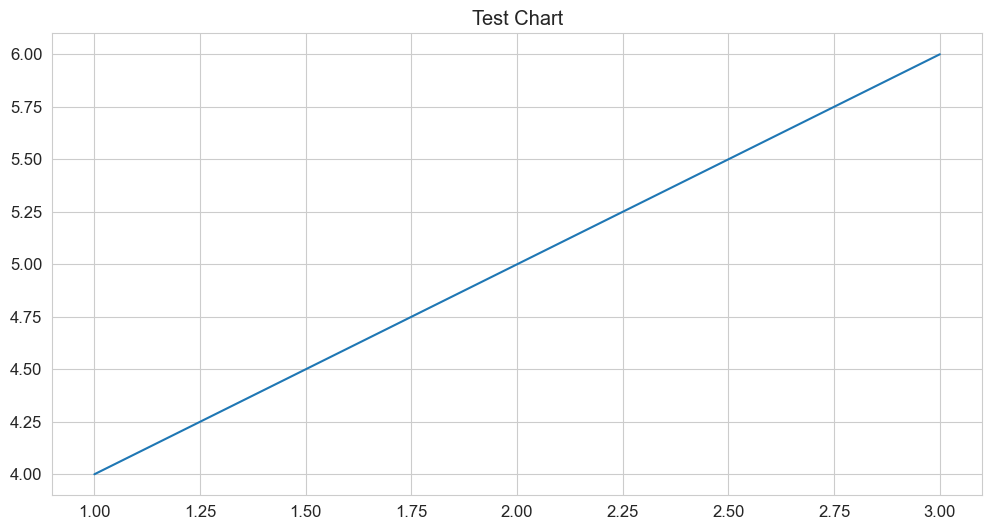

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure()
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Test Chart")
plt.show()

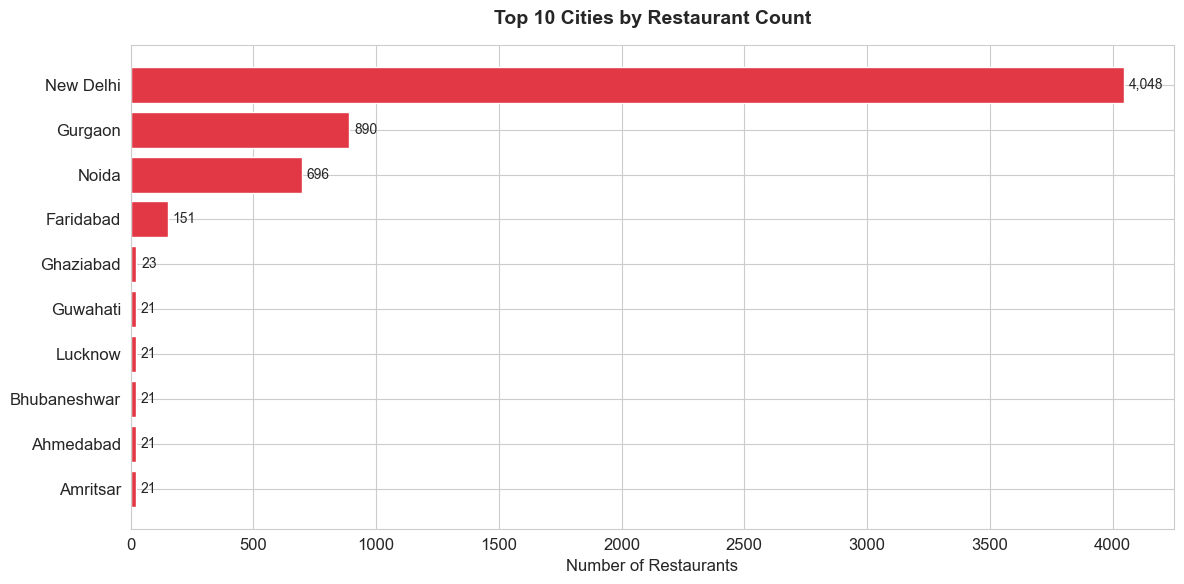

In [13]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('zomato_clean.csv')
df_rated = df[df['Aggregate rating'] > 0]
df_india = df_rated[df_rated['Country Code'] == 1]

sns.set_style('whitegrid')

# Prepare data
city_counts = df_india['City'].value_counts().head(10).reset_index()
city_counts.columns = ['City', 'Total Restaurants']

# Build chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(city_counts['City'], city_counts['Total Restaurants'],
               color='#E23744')

# Add number labels on each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', va='center', fontsize=10)

# Formatting
ax.set_xlabel('Number of Restaurants')
ax.set_title('Top 10 Cities by Restaurant Count', 
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart1_cities.png', dpi=150, bbox_inches='tight')
plt.show()

#### Chart2

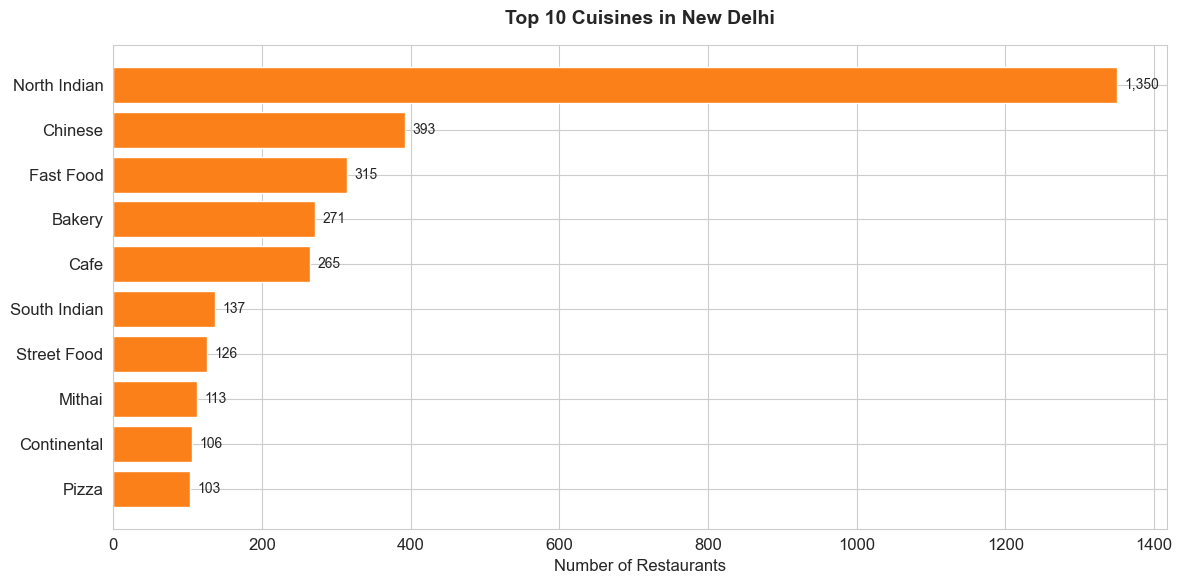

In [14]:
# Prepare data
delhi = df_india[df_india['City'] == 'New Delhi']
cuisine_counts = delhi['Primary Cuisine'].value_counts().head(10).reset_index()
cuisine_counts.columns = ['Cuisine', 'Total Restaurants']

# Build chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cuisine_counts['Cuisine'], cuisine_counts['Total Restaurants'],
               color='#FC8019')

# Add number labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 10, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', va='center', fontsize=10)

# Formatting
ax.set_xlabel('Number of Restaurants')
ax.set_title('Top 10 Cuisines in New Delhi', 
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_cuisines.png', dpi=150, bbox_inches='tight')
plt.show()

#### Chart3

In [15]:
# Prepare data
price_rating = df_india.groupby('Price range').agg(
    avg_rating=('Aggregate rating', 'mean'),
    total=('Restaurant Name', 'count')
).reset_index()
price_rating['avg_rating'] = price_rating['avg_rating'].round(2)

# Replace price range numbers with labels
price_rating['Price range'] = price_rating['Price range'].map({
    1: 'Budget\n(₹<500)',
    2: 'Mid\n(₹500-1000)',
    3: 'Premium\n(₹1000-2000)',
    4: 'Luxury\n(₹2000+)'
})

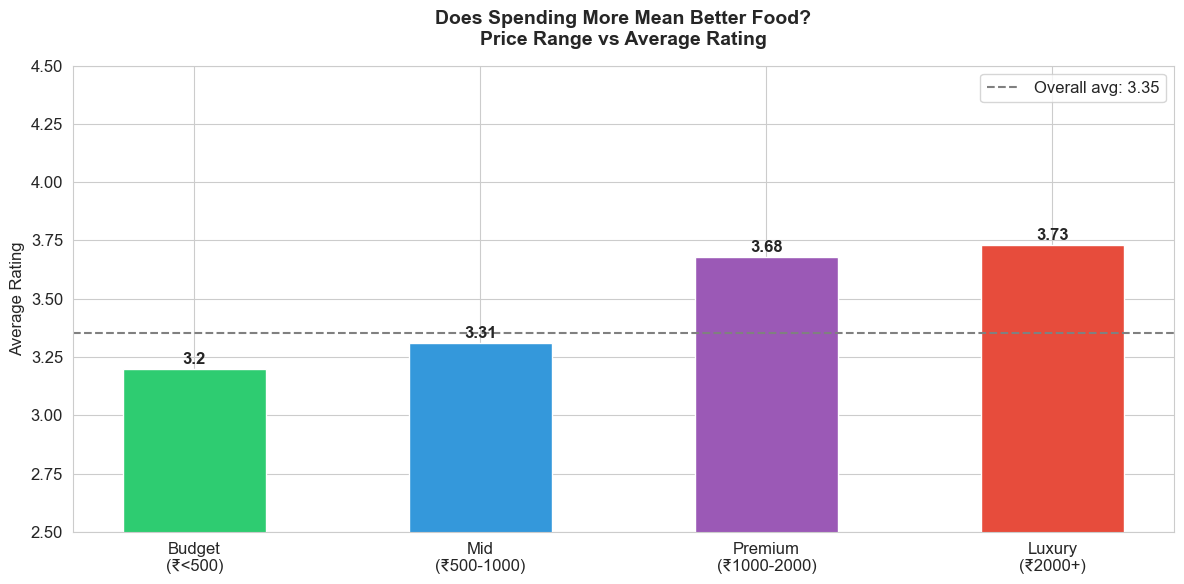

In [16]:
# Build chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(price_rating['Price range'], price_rating['avg_rating'],
              color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'],
              width=0.5)

# Add rating labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f'{height}', ha='center', fontsize=12, fontweight='bold')

# Add a horizontal average line
avg = df_india['Aggregate rating'].mean()
ax.axhline(y=avg, color='gray', linestyle='--', linewidth=1.5, 
           label=f'Overall avg: {avg:.2f}')

# Formatting
ax.set_ylabel('Average Rating')
ax.set_title('Does Spending More Mean Better Food?\nPrice Range vs Average Rating',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(2.5, 4.5)
ax.legend()
plt.tight_layout()
plt.savefig('chart3_price_rating.png', dpi=150, bbox_inches='tight')
plt.show()

#### Chart4

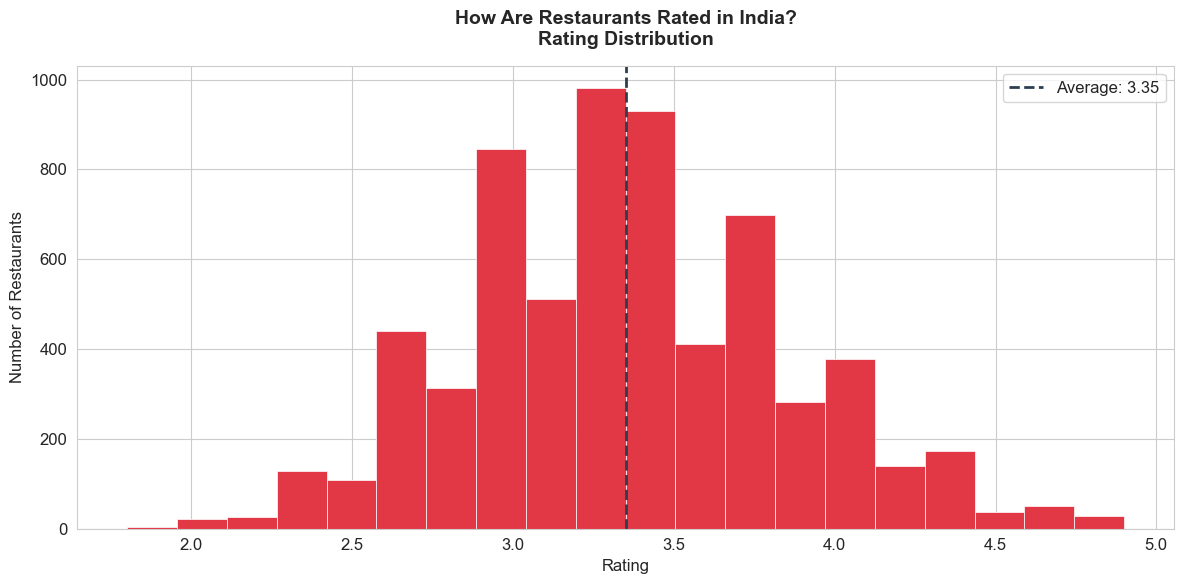

In [17]:
# Prepare data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram
ax.hist(df_india['Aggregate rating'], bins=20, 
        color='#E23744', edgecolor='white', linewidth=0.5)

# Add vertical average line
avg = df_india['Aggregate rating'].mean()
ax.axvline(x=avg, color='#2c3e50', linestyle='--', 
           linewidth=2, label=f'Average: {avg:.2f}')

# Formatting
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Restaurants')
ax.set_title('How Are Restaurants Rated in India?\nRating Distribution',
             fontsize=14, fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('chart4_rating_dist.png', dpi=150, bbox_inches='tight')
plt.show()

#### Chart5

C:\Users\Nupur\AppData\Local\Temp\ipykernel_12392\2107302247.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Delivery', 'Has Delivery'], fontsize=12)


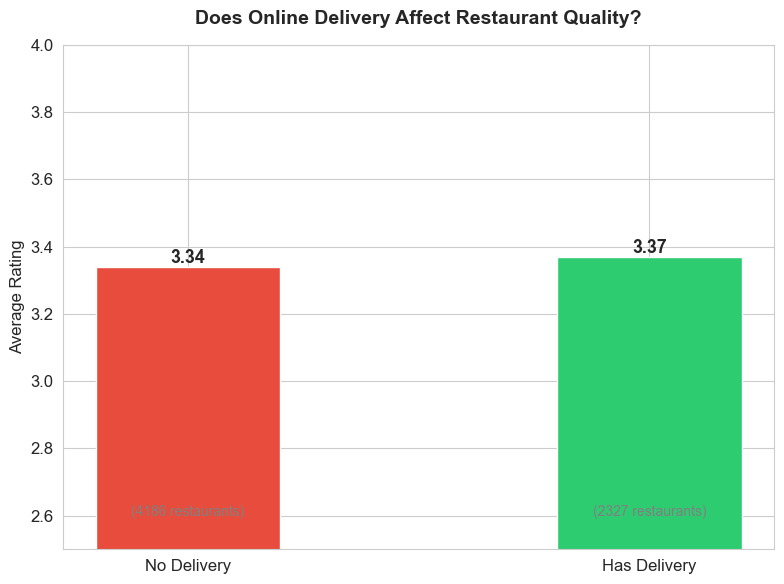

In [18]:
# Prepare data
delivery_data = df_india.groupby('Has Online delivery').agg(
    avg_rating=('Aggregate rating', 'mean'),
    count=('Restaurant Name', 'count')
).reset_index()
delivery_data['avg_rating'] = delivery_data['avg_rating'].round(2)

# Build chart
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(delivery_data['Has Online delivery'], 
              delivery_data['avg_rating'],
              color=colors, width=0.4)

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{height}', ha='center', fontsize=13, fontweight='bold')

# Add count labels below x axis labels
for i, row in delivery_data.iterrows():
    ax.text(i, 2.6, f'({row["count"]} restaurants)', 
            ha='center', fontsize=10, color='gray')

# Formatting
ax.set_ylabel('Average Rating')
ax.set_title('Does Online Delivery Affect Restaurant Quality?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(['No Delivery', 'Has Delivery'], fontsize=12)
ax.set_ylim(2.5, 4.0)
plt.tight_layout()
plt.savefig('chart5_delivery.png', dpi=150, bbox_inches='tight')
plt.show()